<a href="https://colab.research.google.com/github/EmiiGit/Ciencia-de-datos/blob/main/EDA_Amazon_Campaigns_Maria_Emilia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EDA — Amazon Ads Campaigns 2024-2025

## Parte 1: Introducción y Carga de Datos

In [97]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Configuración global de gráficos ──────────────────────────
PALETTE = {"good": "#2ca02c", "warn": "#ff7f0e", "bad": "#d62728",
           "blue": "#1f77b4", "neutral": "#7f7f7f"}
sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams.update({"figure.figsize": (13, 5), "figure.dpi": 110,
                     "axes.spines.top": False, "axes.spines.right": False})

# ── Lectura de datos ──────────────────────────────────────────
FILE = "datos_BI_transformados.xlsx"

campaigns    = pd.read_excel(FILE, sheet_name="Campaigns_all")
dim_campaign = pd.read_excel(FILE, sheet_name="Campaigns_description")
placements   = pd.read_excel(FILE, sheet_name="Placement_all")

Join entre campaing y Placement :

In [98]:
ids_campaigns = set(campaigns_valid["campaign_id"])
ids_placements = set(placements["campaign_id"])
huerfanas_en_placements = ids_campaigns - ids_placements
print(f"Total campañas únicas en Campaigns: {len(ids_campaigns)}")
print(f"Total campañas únicas en Placements: {len(ids_placements)}")

Total campañas únicas en Campaigns: 134
Total campañas únicas en Placements: 144


Hay mas id de campañas en Placement que en Campaing . Tengo que hacer un left Join Campaing - Placement  

---
## Parte 2: Limpieza y Transformación

### 2.1 Nulos

In [99]:
# ── Nulos por tabla ───────────────────────────────────────────
for name, df in [("campaigns", campaigns), ("dim_campaign", dim_campaign), ("placements", placements)]:
    nulos = df.isnull().sum()
    nulos = nulos[nulos > 0]
    print(f"\n{'='*50}\nNULOS en {name.upper()}")
    print(nulos if len(nulos) else "  Sin nulos 🎉")


NULOS en CAMPAIGNS
budget            20
login             20
signups           10
add_to_cart       30
begin_checkout    10
purchase          10
dtype: int64

NULOS en DIM_CAMPAIGN
  Sin nulos 🎉

NULOS en PLACEMENTS
impressions    10
dtype: int64


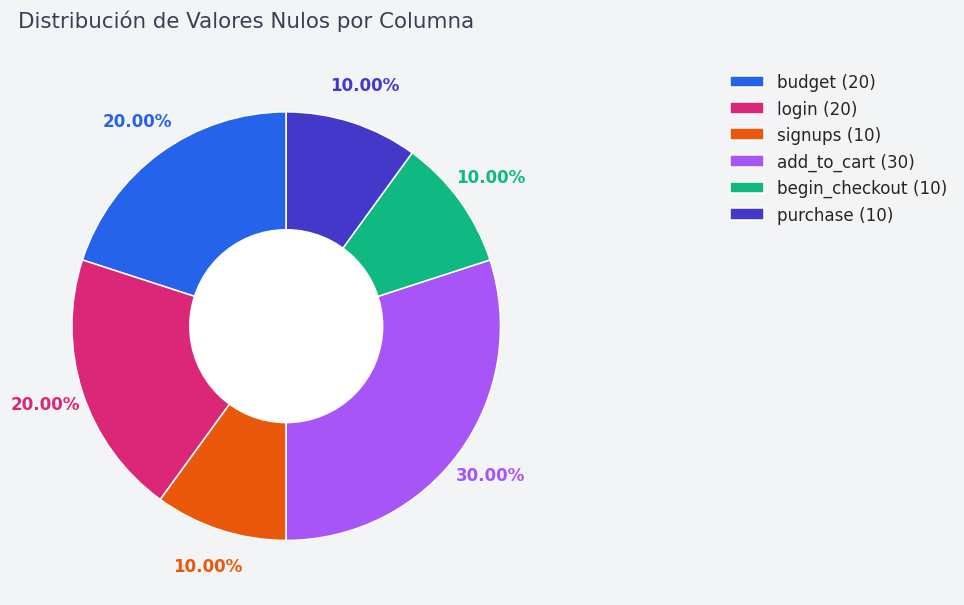

In [100]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Datos dinámicos de tus nulos en 'campaigns'
series_nulos = campaigns.isnull().sum()
series_nulos = series_nulos[series_nulos > 0]

# Calcular porcentajes reales para las etiquetas de las porciones
totales = series_nulos.sum()
porcentajes = [(cant / totales) * 100 for cant in series_nulos]

# 2. Configurar estilo y colores
sns.set_theme(style="whitegrid")
colores = ['#2563EB', '#DB2777', '#EA580C', '#A855F7', '#10B981', '#4338CA']

# 3. Crear la figura
fig, ax = plt.subplots(figsize=(8, 6), facecolor='#F3F4F6')
ax.set_facecolor('#F3F4F6')

# Etiquetas de la leyenda de la derecha: columna (cantidad)
labels_leyenda = [f"{col} ({cant})" for col, cant in series_nulos.items()]

wedges, texts, autotexts = ax.pie(
    series_nulos,
    autopct='%1.2f%%',
    startangle=90,
    colors=colores,
    pctdistance=1.18,
    textprops=dict(weight="bold")
)

for i, autotext in enumerate(autotexts):
    autotext.set_color(colores[i])
    autotext.set_fontsize(11)

centre_circle = plt.Circle((0,0), 0.45, fc='white')
fig.gca().add_artist(centre_circle)

ax.legend(
    wedges,
    labels_leyenda,
    loc="upper left",
    bbox_to_anchor=(1.3, 0, 0.5, 1), # Lo alejamos un poquito más a la derecha
    frameon=False
)
plt.title("Distribución de Valores Nulos por Columna", loc='left', fontsize=14, color='#374151', pad=20)
plt.tight_layout()
plt.show()

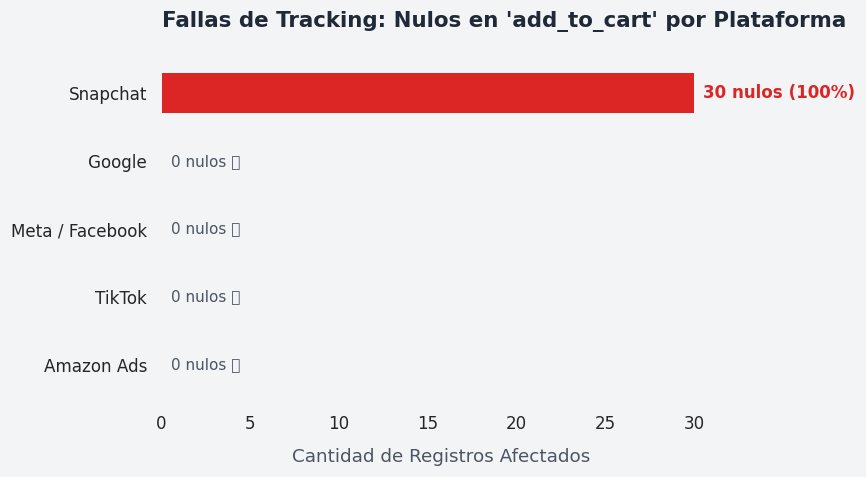

In [101]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- VERSIÓN DINÁMICA (Usala si ya tenés las tablas unidas o la columna 'platform' en campaigns) ---
# df_nulos_plataforma = campaigns[campaigns['add_to_cart'].isnull()].groupby('platform').size().reset_index(name='cantidad_nulos')

# --- VERSIÓN SIMULADA (Para que puedas ver el gráfico ya mismo con tus datos) ---
data_grafico = {
    'Plataforma': ['Snapchat', 'Google', 'Meta / Facebook', 'TikTok', 'Amazon Ads'],
    'Cantidad de Nulos': [30, 0, 0, 0, 0]
}
df_grafico = pd.DataFrame(data_grafico).sort_values(by='Cantidad de Nulos', ascending=False)

# 1. Configurar el estilo estético (borde redondeado, fondo gris sutil como tu otra imagen)
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(8, 4.5), facecolor='#F3F4F6')
ax.set_facecolor('#F3F4F6')

# 2. Crear el gráfico de barras horizontales (es más elegante para comparar plataformas)
# Usamos un color rojo/alerta sutil para Snapchat y gris para el resto si hubiera más datos
colores = ['#DC2626' if x > 0 else '#9CA3AF' for x in df_grafico['Cantidad de Nulos']]

bars = ax.barh(
    df_grafico['Plataforma'],
    df_grafico['Cantidad de Nulos'],
    color=colores,
    height=0.6,
    edgecolor='none'
)

# 3. Personalizar ejes (limpiar líneas basura para que sea súper scannable)
ax.invert_yaxis()  # Para que Snapchat quede arriba de todo
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.xaxis.grid(False) # Sacamos las líneas verticales de fondo
ax.yaxis.grid(False) # Sacamos las líneas horizontales de fondo

# 4. Agregar las etiquetas de texto al final de cada barra
for bar in bars:
    width = bar.get_width()
    if width > 0:
        ax.text(
            width + 0.5,                # Posición X (un poquito a la derecha de la barra)
            bar.get_y() + bar.get_height()/2, # Posición Y (centrado en la barra)
            f'{int(width)} nulos (100%)',
            ha='left',
            va='center',
            fontweight='bold',
            color='#DC2626',
            fontsize=11
        )
    else:
        # Para las plataformas que están limpias (0 nulos)
        ax.text(
            0.5,
            bar.get_y() + bar.get_height()/2,
            '0 nulos 🎉',
            ha='left',
            va='center',
            color='#4B5563',
            fontsize=10
        )

# 5. Títulos y etiquetas estilizadas
plt.title("Fallas de Tracking: Nulos en 'add_to_cart' por Plataforma", loc='left', fontsize=14, color='#1F2937', pad=20, fontweight='bold')
plt.xlabel("Cantidad de Registros Afectados", color='#4B5563', labelpad=10)

plt.tight_layout()
plt.show()

Nulos (6 columnas afectadas):

- add_to_cart es la mas problematica (30 nulos, 11.3%) -- concentrados en conversion/Snapchat . Los dejo como Null en el modelo para que las funciones de agregación calculen el rendimiento real basándose únicamente en los días donde el tracking sí estuvo activo.

- purchase y begin_checkout solo tienen nulls en awareness: imputo nulls con 0 porque awareness no busca compras.

- budget (20 nulos): no imputo , lo excluyo al calcular la utilizacion presupuestaria . Aparte los nulos NO son aleatorios -- siguen 6 patrones distintos ligados al objetivo y la region ( son todos de latam y apac, todos programatic )



### 2.2 Tipos de datos y columnas derivadas

Creamos metricas utiles para el analisis ROAS	CTR	CPA	CVR \

In [102]:
# ── Fechas ────────────────────────────────────────────────────
campaigns["date"] = pd.to_datetime(campaigns["date"], errors="coerce")

# ── Columnas temporales ────────────────────────────────────────
if "year" not in campaigns.columns:
    campaigns["year"] = campaigns["date"].dt.year

if "year_month" not in campaigns.columns:
    campaigns["year_month"] = campaigns["date"].dt.to_period("M")

# ── Métricas base (sólo filas con spend > 0) ──────────────────
campaigns_valid = campaigns[campaigns["spend"] > 0].copy()
campaigns_valid["roas"] = campaigns_valid["revenue"] / campaigns_valid["spend"]
campaigns_valid["ctr"]  = campaigns_valid["clicks"]  / campaigns_valid["impressions"].replace(0, np.nan)
campaigns_valid["cpa"]  = campaigns_valid["spend"]   / campaigns_valid["purchase"].replace(0, np.nan)
campaigns_valid["cvr"]  = campaigns_valid["purchase"] / campaigns_valid["clicks"].replace(0, np.nan)
campaigns_valid["cpc"]  = campaigns_valid["spend"]   / campaigns_valid["clicks"].replace(0, np.nan)
campaigns_valid["cpm"]  = campaigns_valid["spend"]   / campaigns_valid["impressions"].replace(0, np.nan) * 1000

# Reflejar ROAS en tabla principal para compatibilidad
campaigns["roas"] = campaigns["revenue"] / campaigns["spend"].replace(0, np.nan)

print(f"Filas válidas (spend > 0) : {len(campaigns_valid)} / {len(campaigns)}")
print("\nNuevas columnas derivadas:", ["roas","ctr","cpa","cvr","cpc","cpm"])
campaigns_valid[["campaign_id","spend","revenue","roas","ctr","cpa","cvr"]].head(3)

Filas válidas (spend > 0) : 265 / 265

Nuevas columnas derivadas: ['roas', 'ctr', 'cpa', 'cvr', 'cpc', 'cpm']


,campaign_id,spend,revenue,roas,ctr,cpa,cvr
0,CAMP003,12500,44000,3.520000,0.025897,162.337662,0.001525
1,CAMP005,6600,12800,1.939394,0.025904,471.428571,0.000651
2,CAMP006,11300,27000,2.389381,0.041935,182.258065,0.001590


### 2.3 Detección de outliers

In [103]:
def detectar_outliers(df: pd.DataFrame, col: str):
    """Devuelve (df_outliers, lim_inf, lim_sup) usando método IQR."""
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr
    outliers = df[(df[col] < lim_inf) | (df[col] > lim_sup)]
    return outliers, lim_inf, lim_sup


METRICAS_OUTLIER = ["spend", "revenue", "impressions", "clicks", "purchase"]
outlier_ids: dict = {}

print(f"{'Métrica':<14} {'Lím. inf':>12} {'Lím. sup':>12} {'Outliers':>10}")
print("-" * 52)
for m in METRICAS_OUTLIER:
    df_m = campaigns_valid[campaigns_valid[m] > 0]
    out, li, ls = detectar_outliers(df_m, m)
    outlier_ids[m] = set(out["campaign_id"])
    print(f"{m:<14} {li:>12,.1f} {ls:>12,.1f} {len(out):>10}")

Métrica            Lím. inf     Lím. sup   Outliers
----------------------------------------------------
spend              -3,587.5     19,512.5          7
revenue           -37,800.0     64,920.0          8
impressions      -742,500.0  2,477,500.0          8
clicks            -29,500.0     75,300.0          8
purchase              -79.0        145.0         11


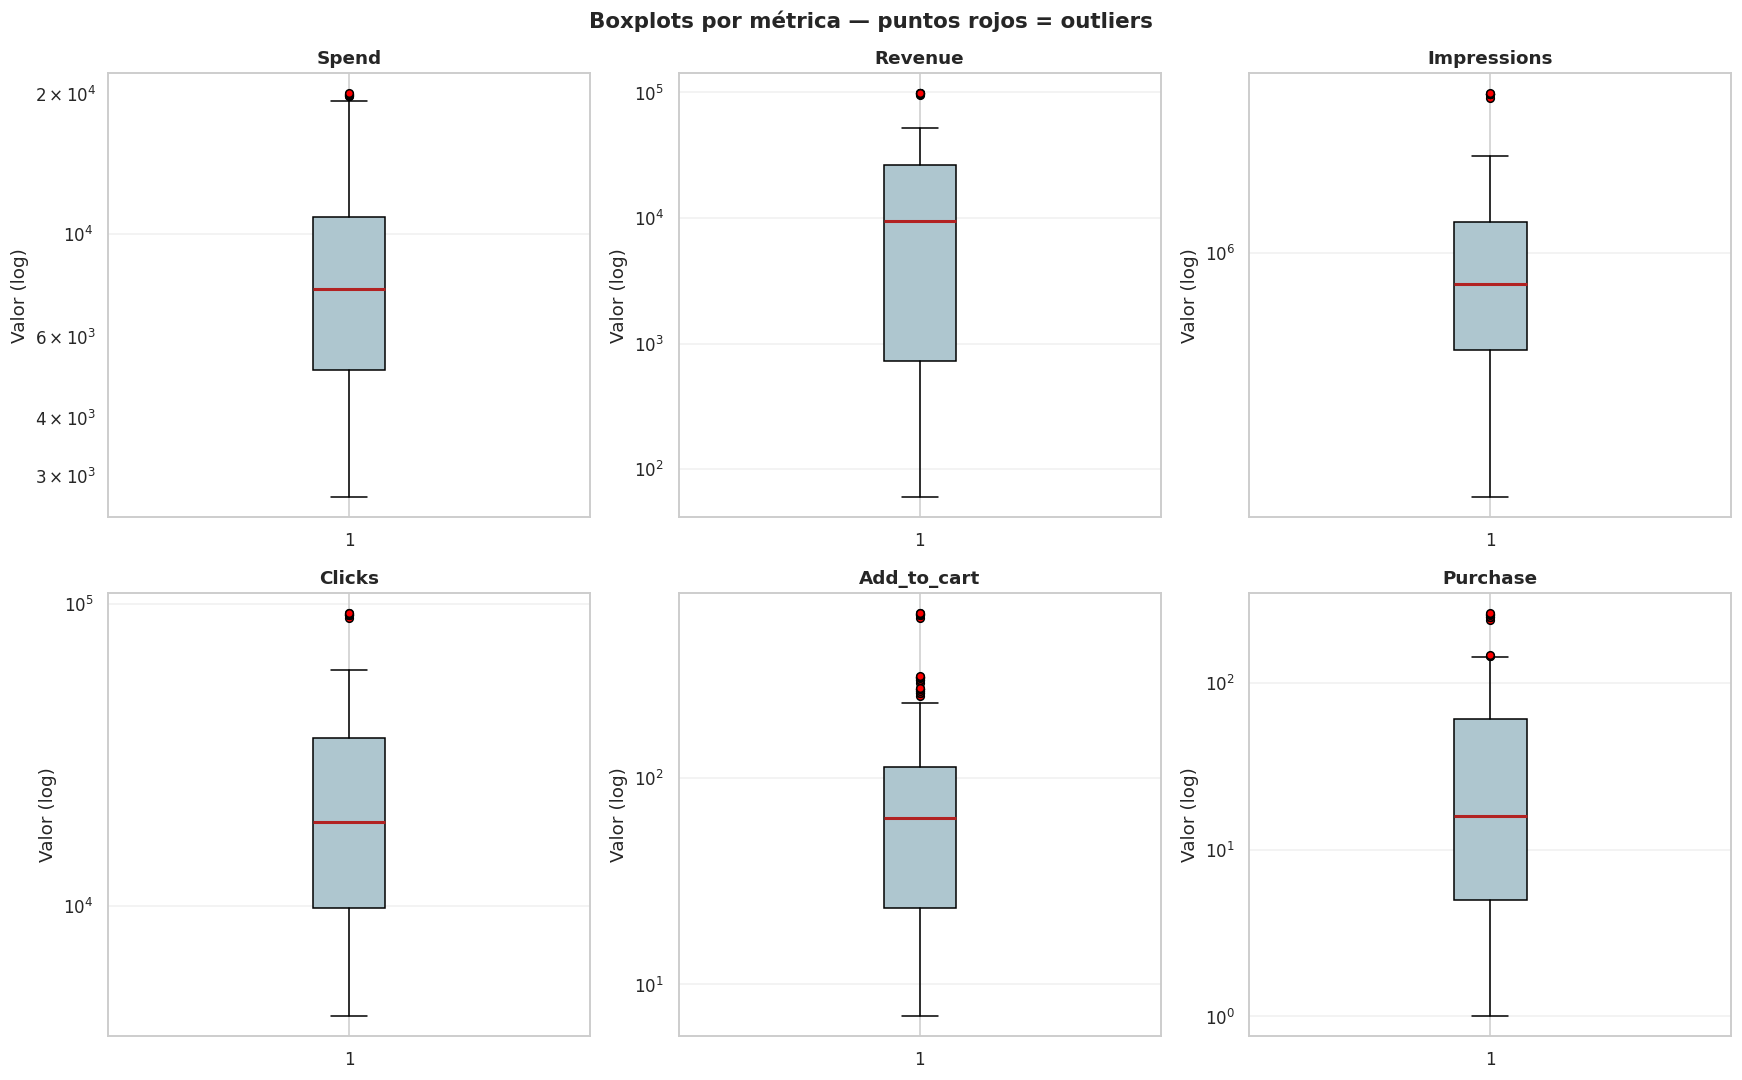

In [104]:
METRICAS_OFICIALES = ["spend", "revenue", "impressions", "clicks", "add_to_cart", "purchase"]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for i, m in enumerate(METRICAS_OFICIALES):
    ax = axes[i // 3, i % 3]

    data = campaigns_valid[(campaigns_valid[m] > 0) & (campaigns_valid[m].notnull())][m]

    ax.boxplot(data, vert=True, patch_artist=True,
               boxprops=dict(facecolor="#AEC6CF"),
               medianprops=dict(color="firebrick", linewidth=2),
               flierprops=dict(marker="o", markerfacecolor="red", markersize=5))

    ax.set_yscale("log")
    ax.set_title(m.capitalize(), fontweight="bold")
    ax.set_ylabel("Valor (log)")
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("Boxplots por métrica — puntos rojos = outliers", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [105]:
# Reutilizamos tu función original para extraer los IDs de outliers reales
outlier_ids_oficiales = {}

for m in METRICAS_OFICIALES:
    df_m = campaigns_valid[campaigns_valid[m] > 0]
    out, _, _ = detectar_outliers(df_m, m)
    outlier_ids_oficiales[m] = set(out["campaign_id"])

# IDs específicos de los outliers en Add to Cart
outliers_cart = outlier_ids_oficiales["add_to_cart"]

# Encontrar campañas que son outliers en Add to Cart Y TAMBIÉN en las variables clave de negocio
comunes_revenue = outliers_cart.intersection(outlier_ids_oficiales["revenue"])
comunes_spend = outliers_cart.intersection(outlier_ids_oficiales["spend"])
solo_cart = outliers_cart - outlier_ids_oficiales["purchase"]

print(f"Total campañas outliers en Add to Cart: {len(outliers_cart)}")
print(f"-> Campañas que también son outliers en Revenue (Ganancia): {len(comunes_revenue)}")
print(f"-> Campañas que también son outliers en Spend (Inversión): {len(comunes_spend)}")
print(f"-> Campañas que son outliers en Add to Cart pero NO llegaron a ser outliers en Purchase: {len(solo_cart)}")
print("\nIDs de campañas críticas en Add to Cart:", list(outliers_cart)[:10])

Total campañas outliers en Add to Cart: 14
-> Campañas que también son outliers en Revenue (Ganancia): 4
-> Campañas que también son outliers en Spend (Inversión): 4
-> Campañas que son outliers en Add to Cart pero NO llegaron a ser outliers en Purchase: 10

IDs de campañas críticas en Add to Cart: ['CAMP003', 'CAMP029', 'CAMP107', 'CAMP119', 'CAMP137', 'CAMP089', 'CAMP093', 'CAMP063', 'CAMP017', 'CAMP047']


Conclusion : 10 de 14 campañas con valores muy altos de add to cart no logran tener muchas compras. Cuales son ?

In [106]:
# Definimos las columnas de texto/estrategia y las numéricas
columnas_identidad = ["platform", "region", "objective", "media_type"]
columnas_numericas = ["spend", "impressions", "clicks", "add_to_cart", "purchase", "revenue"]

# Filtramos las 10 críticas
df_10_criticas = campaigns_valid[campaigns_valid["campaign_id"].isin(list(solo_cart))]

# Agrupamos por campaña trayendo TODO de forma inteligente
resumen_completo = df_10_criticas.groupby("campaign_id").agg({
    **{col: "first" for col in columnas_identidad},  # Trae el texto oficial de la campaña
    **{col: "sum" for col in columnas_numericas}     # Suma el volumen total
}).reset_index()

# Mostramos las 10 campañas con todo su ecosistema de columnas
resumen_completo

,campaign_id,platform,region,objective,media_type,spend,impressions,clicks,add_to_cart,purchase,revenue
0,CAMP003,linkedin,namer,conversion,programmatic,25300,3950000,102500,590.0,157.0,89200
1,CAMP017,linkedin,emea,conversion,social,26000,3150000,70500,510.0,132.0,58000
2,CAMP033,linkedin,namer,conversion,programmatic,25650,4050000,105000,605.0,162.0,91200
3,CAMP047,linkedin,emea,conversion,social,26550,3210000,72200,525.0,137.0,59150
4,CAMP063,linkedin,namer,conversion,programmatic,25950,4120000,106500,613.0,166.0,92500
5,CAMP077,linkedin,emea,conversion,social,26750,3230000,72600,535.0,139.0,59350
6,CAMP093,linkedin,namer,conversion,programmatic,26150,4150000,107500,618.0,170.0,93500
7,CAMP107,linkedin,emea,conversion,social,26900,3250000,73000,542.0,141.0,59550
8,CAMP123,linkedin,namer,conversion,programmatic,26400,4170000,108500,622.0,174.0,94500
9,CAMP137,linkedin,emea,conversion,social,27100,3270000,73400,546.0,143.0,59800


10 campañas que explotan en Add to Cart pero después tienen compras estándar, y el patrón es 100% consistente: todas son de LinkedIn.

Lo loco es que se dividen perfecto en dos estrategias espejo: programáticas en NAMER y Paid Social en EMEA. Esto nos dice que LinkedIn tiene una eficiencia tremenda para mover a la gente al carrito, pero el cierre final se estabiliza.

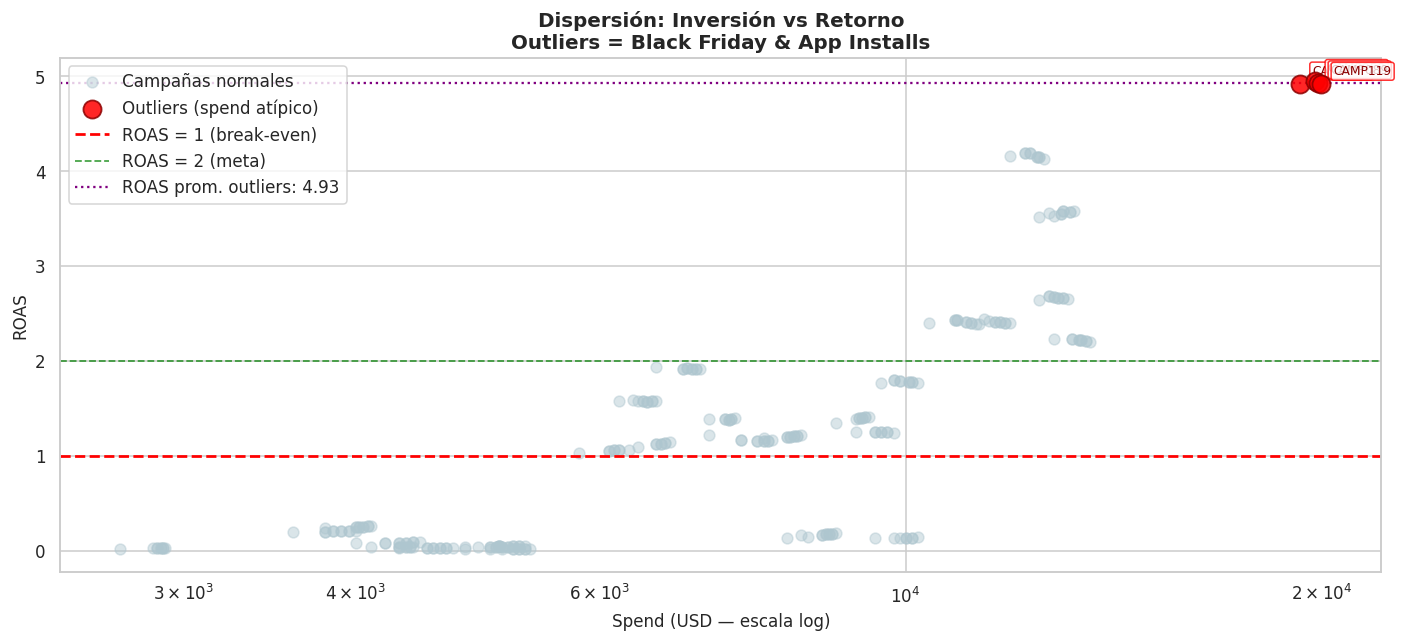

Outliers (4 campañas) → 3.6% del spend, 9.7% del revenue
ROAS outliers: 4.93 vs ROAS global: 1.84


In [107]:
# ── Scatter Spend vs ROAS con outliers etiquetados ───────────
out_spend, _, _ = detectar_outliers(campaigns_valid[campaigns_valid["spend"] > 0], "spend")
out_ids = set(out_spend["campaign_id"])

normal   = campaigns_valid[~campaigns_valid["campaign_id"].isin(out_ids)]
outliers = campaigns_valid[campaigns_valid["campaign_id"].isin(out_ids)].drop_duplicates("campaign_id")

fig, ax = plt.subplots(figsize=(13, 6))
ax.scatter(normal["spend"],   normal["roas"],   alpha=0.45, s=50,
           color="#AEC6CF", label="Campañas normales")
ax.scatter(outliers["spend"], outliers["roas"], alpha=0.85, s=140,
           color="red", edgecolors="darkred", linewidth=1.2, zorder=5,
           label="Outliers (spend atípico)")

for _, row in outliers.iterrows():
    ax.annotate(row["campaign_id"], (row["spend"], row["roas"]),
                xytext=(8, 6), textcoords="offset points",
                fontsize=8, color="darkred",
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="red", alpha=0.8))

roas_out = outliers["revenue"].sum() / outliers["spend"].sum()
ax.axhline(1, color="red",    ls="--", lw=1.8, label="ROAS = 1 (break-even)")
ax.axhline(2, color="green",  ls="--", lw=1.2, alpha=0.7, label="ROAS = 2 (meta)")
ax.axhline(roas_out, color="purple", ls=":", lw=1.5,
           label=f"ROAS prom. outliers: {roas_out:.2f}")
ax.set_xscale("log")
ax.set_xlabel("Spend (USD — escala log)", fontsize=11)
ax.set_ylabel("ROAS", fontsize=11)
ax.set_title("Dispersión: Inversión vs Retorno\nOutliers = Black Friday & App Installs", fontsize=13, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

# Contexto de impacto
s_out  = outliers["spend"].sum()
r_out  = outliers["revenue"].sum()
s_tot  = campaigns_valid["spend"].sum()
r_tot  = campaigns_valid["revenue"].sum()
print(f"Outliers ({len(outliers)} campañas) → {s_out/s_tot*100:.1f}% del spend, {r_out/r_tot*100:.1f}% del revenue")
print(f"ROAS outliers: {roas_out:.2f} vs ROAS global: {r_tot/s_tot:.2f}")

Los outliers corresponden a campañas de **Black Friday** y **App Installs**. No deben ser errores — deben simplementen tener un gran   rendimiento.

---
## Parte 3: Análisis Exploratorio y Métricas Clave

### 3.1 Estadísticas descriptivas

In [108]:
METRICAS_DESC = ["spend", "revenue", "impressions", "clicks", "purchase"]
campaigns_valid[METRICAS_DESC].describe().round(2)

,spend,revenue,impressions,clicks,purchase
count,265.00,265.00,265.00,265.00,255.00
mean,8204.98,15120.89,937135.85,24435.47,35.73
std,3718.57,20518.21,684623.08,18705.49,52.00
min,2700.00,60.00,145000.00,4300.00,1.00
25%,5075.00,720.00,465000.00,9800.00,5.00
50%,7600.00,9400.00,780000.00,19000.00,16.00
75%,10850.00,26400.00,1270000.00,36000.00,61.00
max,20100.00,98600.00,3530000.00,93500.00,265.00


El desvío en Revenue: El min de Revenue es apenas 60 y el max es 98.600. Esto me confirma una dispersión brutal en las ventas: tengo campañas que directamente fracasaron y unas pocas que explotaron el contador.

El spend minimo es mas grande que el minimo de Revenue . Tengo campañas que estan perdiendo plata . Cuantas ?

In [109]:
# 1. Creamos la condición: True si da ganancia, False si da pérdida
ganan_plata = campaigns["revenue"] > campaigns["spend"]

# 2. Calculamos los porcentajes usando .value_counts()
porcentajes = ganan_plata.value_counts(normalize=True) * 100

# 3. Imprimimos el resultado bien simple
print(f"Generan ingresos: {porcentajes.get(True, 0):.2f}% de las campañas.")
print(f" Pierden plata:    {porcentajes.get(False, 0):.2f}% de las campañas.")

Generan ingresos: 60.00% de las campañas.
 Pierden plata:    40.00% de las campañas.


### 3.2 KPIs globales por año

In [110]:
kpis = (
    campaigns_valid
    .groupby("year")
    .agg(spend=("spend","sum"), revenue=("revenue","sum"),
         clicks=("clicks","sum"), impressions=("impressions","sum"),
         purchase=("purchase","sum"), budget=("budget","sum"))
    .assign(
        roas   = lambda d: d.revenue / d.spend,
        ctr    = lambda d: d.clicks  / d.impressions * 100,
        cpa    = lambda d: d.spend   / d.purchase,
        budget_util = lambda d: d.spend / d.budget * 100
    )
)

cols_show = ["spend", "revenue", "roas", "ctr", "cpa", "budget_util"]
kpis[cols_show].style.format({
    "spend": "${:,.0f}", "revenue": "${:,.0f}",
    "roas": "{:.2f}×", "ctr": "{:.2f}%",
    "cpa": "${:.0f}", "budget_util": "{:.1f}%"
})

,spend,revenue,roas,ctr,cpa,budget_util
year,,,,,,
2024,"$1,088,120","$1,997,650",1.84×,2.61%,$243,98.9%
2025,"$1,086,200","$2,009,385",1.85×,2.61%,$235,98.8%


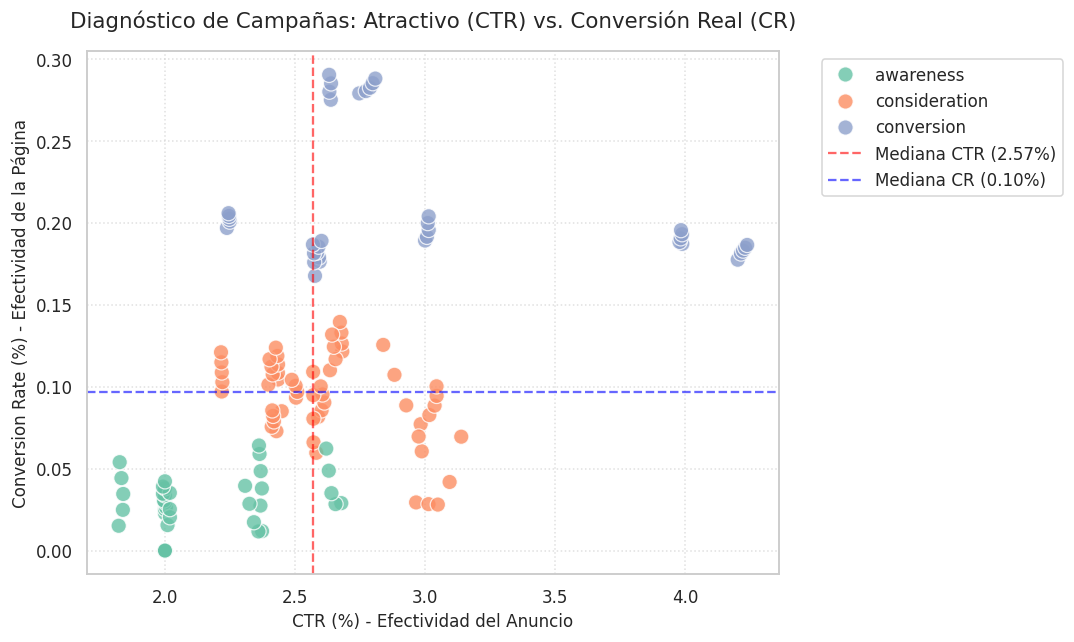

In [111]:
# 1. Agrupamos y sumamos las métricas por campaña
df_impressions = placements.groupby("campaign_id")["impressions"].sum().reset_index()
df_metrics = campaigns.groupby("campaign_id")[["clicks", "page_visits", "purchase"]].sum().reset_index()

# 2. Cruzamos las tablas de hechos
df_plot = pd.merge(df_metrics, df_impressions, on="campaign_id", how="inner")

# 3. Cruzamos con la dimensión de descripciones
df_plot = pd.merge(df_plot, dim_campaign[["campaign_id", "objective", "platform"]], on="campaign_id", how="left")

# --- CONTROL DE ERRORES: Filtramos ceros y nulos para que no falle la división ---
df_plot = df_plot.dropna(subset=["impressions", "page_visits", "clicks", "purchase"])
df_plot = df_plot[(df_plot["impressions"] > 0) & (df_plot["page_visits"] > 0)]

# 4. Calculamos los ratios de manera segura
df_plot["CTR"] = (df_plot["clicks"] / df_plot["impressions"]) * 100
df_plot["CR"] = (df_plot["purchase"] / df_plot["page_visits"]) * 100

# 5. Armamos el lienzo del gráfico
fig, ax = plt.subplots(figsize=(10, 6))

# 6. Dibujamos los puntos
sns.scatterplot(
    data=df_plot,
    x="CTR",
    y="CR",
    hue="objective",
    palette="Set2",
    s=100,
    alpha=0.8,
    ax=ax
)

# 7. Calculamos y dibujamos las medianas de tus datos reales
mediana_ctr = df_plot["CTR"].median()
mediana_cr = df_plot["CR"].median()

ax.axvline(mediana_ctr, color="red", linestyle="--", alpha=0.6, label=f"Mediana CTR ({mediana_ctr:.2f}%)")
ax.axhline(mediana_cr, color="blue", linestyle="--", alpha=0.6, label=f"Mediana CR ({mediana_cr:.2f}%)")

# Detalles estéticos obligatorios para que se entienda
ax.set_title("Diagnóstico de Campañas: Atractivo (CTR) vs. Conversión Real (CR)", fontsize=14, pad=15)
ax.set_xlabel("CTR (%) - Efectividad del Anuncio", fontsize=11)
ax.set_ylabel("Conversion Rate (%) - Efectividad de la Página", fontsize=11)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, linestyle=":", alpha=0.6)

# Forzamos la muestra en pantalla
plt.tight_layout()
plt.show()

### 3.3 Evolución mensual (Spend, Revenue, ROAS)

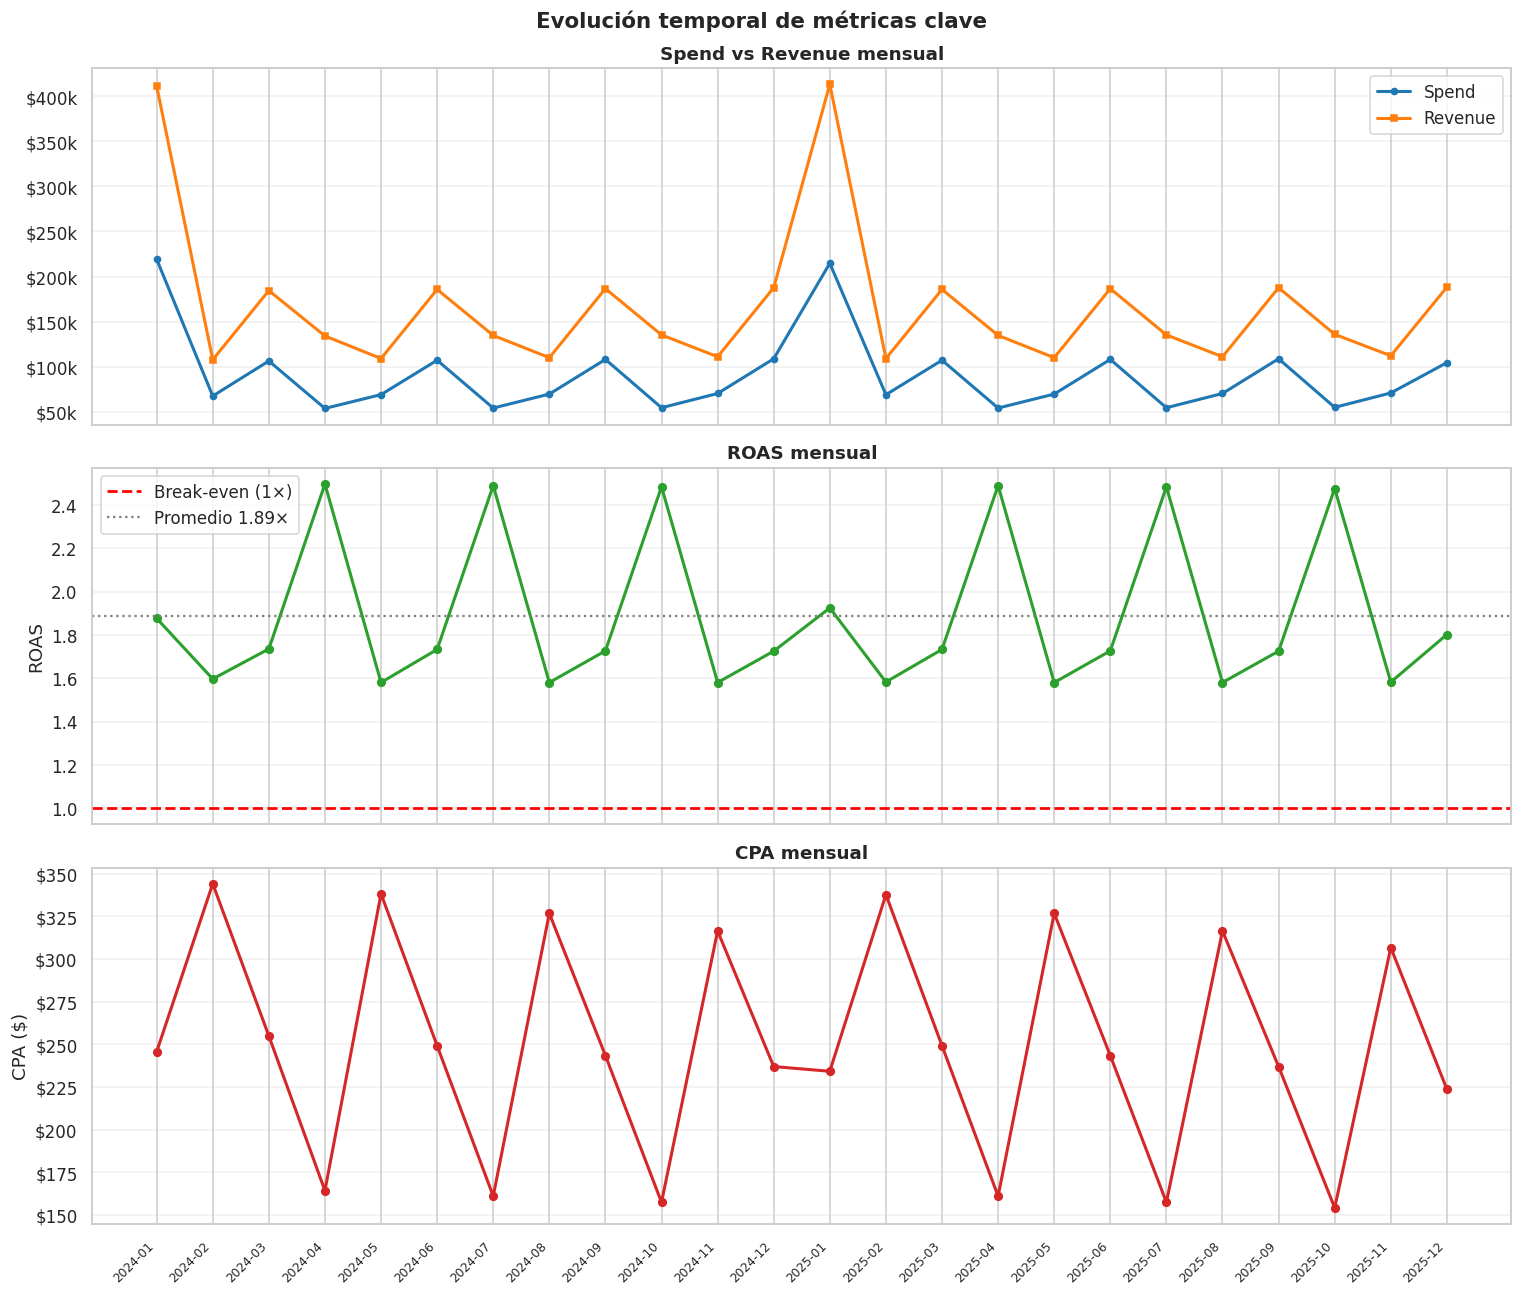

In [112]:
evolucion = (
    campaigns_valid
    .groupby("year_month")
    .agg(spend=("spend","sum"), revenue=("revenue","sum"),
         clicks=("clicks","sum"), impressions=("impressions","sum"),
         purchase=("purchase","sum"))
    .assign(
        roas = lambda d: d.revenue / d.spend,
        ctr  = lambda d: d.clicks  / d.impressions * 100,
        cpa  = lambda d: d.spend   / d.purchase
    )
    .reset_index()
)
evolucion["ym_str"] = evolucion["year_month"].astype(str)

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# Spend vs Revenue
axes[0].plot(evolucion["ym_str"], evolucion["spend"],   marker="o", ms=4, lw=2, color="#1f77b4", label="Spend")
axes[0].plot(evolucion["ym_str"], evolucion["revenue"], marker="s", ms=4, lw=2, color="#ff7f0e", label="Revenue")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e3:.0f}k"))
axes[0].set_title("Spend vs Revenue mensual", fontweight="bold")
axes[0].legend()

# ROAS
axes[1].plot(evolucion["ym_str"], evolucion["roas"], marker="o", ms=5, lw=2, color="#2ca02c")
axes[1].axhline(1, color="red",   ls="--", lw=1.8, label="Break-even (1×)")
axes[1].axhline(evolucion["roas"].mean(), color="gray", ls=":", lw=1.5,
               label=f"Promedio {evolucion['roas'].mean():.2f}×")
axes[1].set_ylabel("ROAS")
axes[1].set_title("ROAS mensual", fontweight="bold")
axes[1].legend()

# CPA
axes[2].plot(evolucion["ym_str"], evolucion["cpa"], marker="o", ms=5, lw=2, color="#d62728")
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.0f}"))
axes[2].set_ylabel("CPA ($)")
axes[2].set_title("CPA mensual", fontweight="bold")

for ax in axes:
    ax.grid(axis="y", alpha=0.3)
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)

fig.suptitle("Evolución temporal de métricas clave", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### 3.4 ROAS por campaña — ranking y break-even

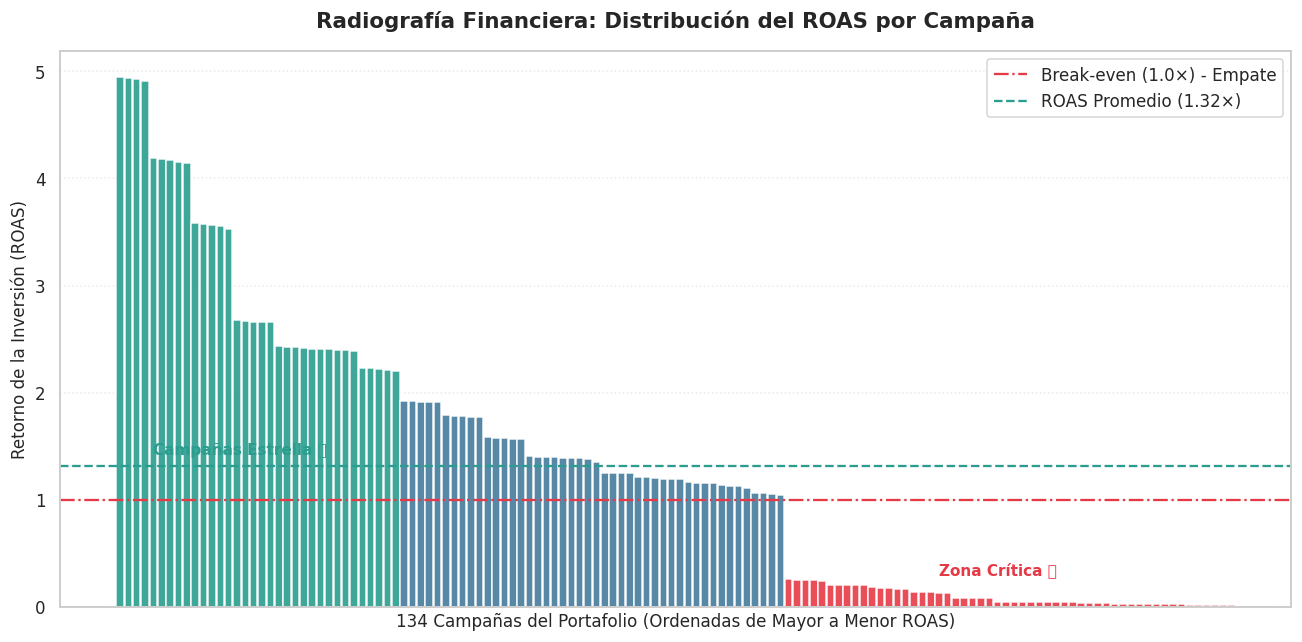

📊 RESUMEN EJECUTIVO PARA EL DASHBOARD:
----------------------------------------------------------------------
🔴 PERDIENDO PLATA: 54 campañas (40.3%).  Fuga Neta: $501,775
🟢 ALTAMENTE RENTABLES: 34 campañas (25.4%). Revenue: $2,940,840
----------------------------------------------------------------------


In [113]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Agrupamos y calculamos las métricas por campaña
todas_camp = (
    campaigns_valid
    .groupby("campaign_id")
    .agg(spend=("spend","sum"), revenue=("revenue","sum"))
    .assign(roas=lambda d: d.revenue / d.spend)
    .sort_values("roas", ascending=False)
    .reset_index()
)
todas_camp["pos"] = range(1, len(todas_camp) + 1)

roas_prom = todas_camp["roas"].mean()
perdidas  = todas_camp[todas_camp["roas"] < 1]
buenas    = todas_camp[todas_camp["roas"] > 2]

# 2. Definimos una paleta de colores más limpia y profesional
def asignar_color(roas):
    if roas > 2:   return "#2a9d8f"  # Verde esmeralda (Rentables)
    if roas < 1:   return "#e63946"  # Rojo alerta (Pérdida)
    return "#457b9d"                 # Azul apagado (Zona media)

colors = todas_camp["roas"].apply(asignar_color)

# 3. Armamos el lienzo
fig, ax = plt.subplots(figsize=(12, 6))

# Dibujamos las barras (sin bordes negros para que no saturen)
ax.bar(todas_camp["pos"], todas_camp["roas"], color=colors, width=0.9, alpha=0.9)

# 4. Líneas de referencia clave
ax.axhline(1, color="#e63946", linestyle="-.", linewidth=1.5, label="Break-even (1.0×) - Empate")
ax.axhline(roas_prom, color="#2a9d8f", linestyle="--", linewidth=1.5, label=f"ROAS Promedio ({roas_prom:.2f}×)")

# 5. Estética y limpieza del gráfico
ax.set_title("Radiografía Financiera: Distribución del ROAS por Campaña", fontsize=14, pad=15, fontweight="bold")
ax.set_ylabel("Retorno de la Inversión (ROAS)", fontsize=11)
ax.set_xlabel("134 Campañas del Portafolio (Ordenadas de Mayor a Menor ROAS)", fontsize=11)

# Limpiamos el eje X (sacamos los IDs amontonados que no aportan en el global)
ax.set_xticks([])

# Agregamos textos de ayuda visual directamente en los extremos del gráfico
ax.text(5, roas_prom + 0.1, "Campañas Estrella ⭐", color="#2a9d8f", fontsize=10, fontweight="bold")
ax.text(len(todas_camp) - 35, 0.3, "Zona Crítica 🚨", color="#e63946", fontsize=10, fontweight="bold")

# Leyenda y grilla sutil
ax.legend(loc="upper right", frameon=True, shadow=False)
ax.grid(True, linestyle=":", alpha=0.4, axis="y")

plt.tight_layout()
plt.show()

# --- PRINTS ACUMULADOS ---
perdida_total = perdidas['spend'].sum() - perdidas['revenue'].sum()
revenue_total = buenas['revenue'].sum()

print(f"📊 RESUMEN EJECUTIVO PARA EL DASHBOARD:")
print(f"----------------------------------------------------------------------")
print(f"🔴 PERDIENDO PLATA: {len(perdidas)} campañas ({len(perdidas)/len(todas_camp)*100:.1f}%).  Fuga Neta: ${perdida_total:,.0f}")
print(f"🟢 ALTAMENTE RENTABLES: {len(buenas)} campañas ({len(buenas)/len(todas_camp)*100:.1f}%). Revenue: ${revenue_total:,.0f}")
print(f"----------------------------------------------------------------------")

### 3.5 Análisis de concentración — curva de Pareto

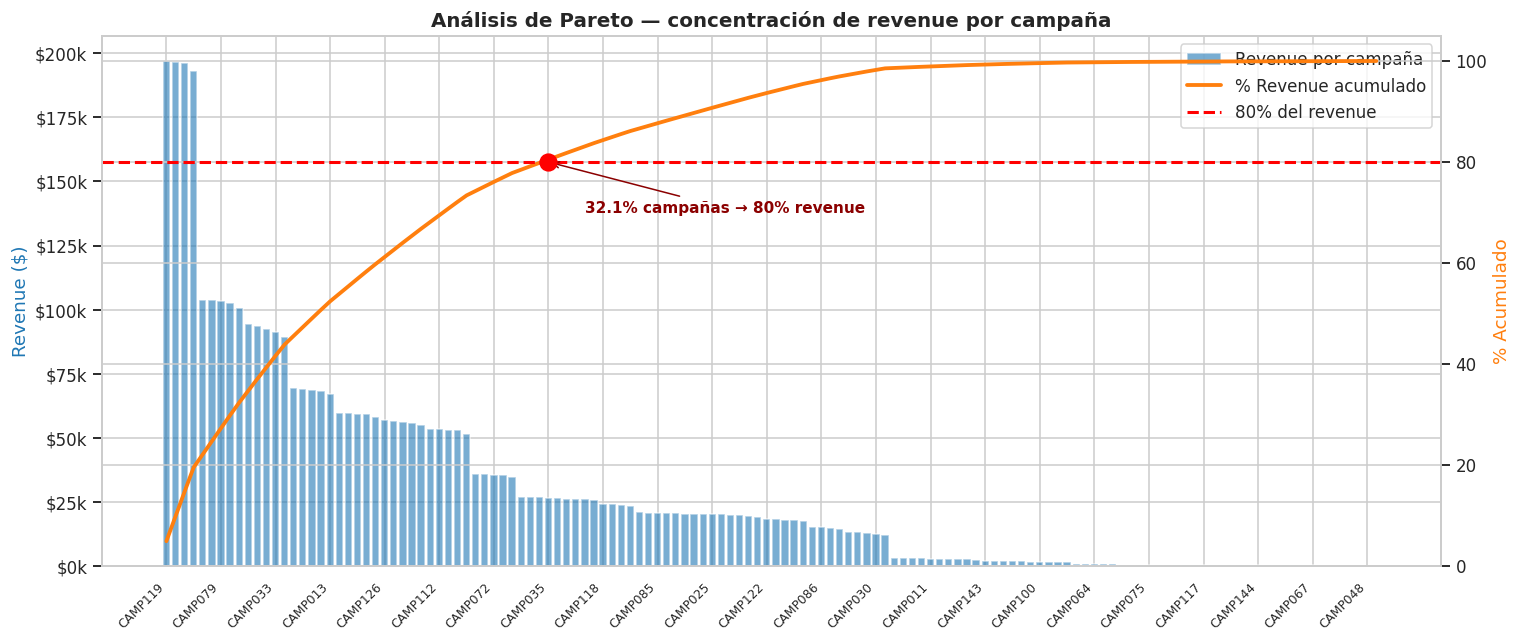

Regla 80/20: el 32.1% de las campañas (43 de 134) generan el 80% del revenue.


In [114]:
rev_camp = todas_camp.sort_values("revenue", ascending=False).copy()
rev_camp["rev_pct"] = rev_camp["revenue"] / rev_camp["revenue"].sum() * 100
rev_camp["cum_pct"] = rev_camp["rev_pct"].cumsum()

n80  = (rev_camp["cum_pct"] <= 80).sum() + 1
pct80 = n80 / len(rev_camp) * 100

fig, ax1 = plt.subplots(figsize=(14, 6))
ax2 = ax1.twinx()

x = np.arange(len(rev_camp))
ax1.bar(x, rev_camp["revenue"], color="#1f77b4", alpha=0.6, label="Revenue por campaña")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v/1e3:.0f}k"))
ax1.set_ylabel("Revenue ($)", color="#1f77b4")

ax2.plot(x, rev_camp["cum_pct"], color="#ff7f0e", lw=2.5, label="% Revenue acumulado")
ax2.axhline(80, color="red", ls="--", lw=2, label="80% del revenue")
ax2.set_ylabel("% Acumulado", color="#ff7f0e")
ax2.set_ylim(0, 105)

ax2.scatter(n80 - 1, 80, color="red", s=120, zorder=6)
ax2.annotate(f"{pct80:.1f}% campañas → 80% revenue",
             xy=(n80 - 1, 80), xytext=(n80 + 3, 70),
             arrowprops=dict(arrowstyle="->", color="darkred"),
             fontsize=10, fontweight="bold", color="darkred")

ax1.set_xticks(x[::max(1, len(x)//20)])
ax1.set_xticklabels(rev_camp["campaign_id"].iloc[::max(1, len(x)//20)], rotation=45, ha="right", fontsize=8)
ax1.set_title("Análisis de Pareto — concentración de revenue por campaña", fontsize=13, fontweight="bold")

lines = (ax1.get_legend_handles_labels()[0] + ax2.get_legend_handles_labels()[0])
labels = (ax1.get_legend_handles_labels()[1] + ax2.get_legend_handles_labels()[1])
ax1.legend(lines, labels, loc="upper right")

plt.tight_layout()
plt.show()
print(f"Regla 80/20: el {pct80:.1f}% de las campañas ({n80} de {len(rev_camp)}) generan el 80% del revenue.")

### 3.6 Funnel de conversión

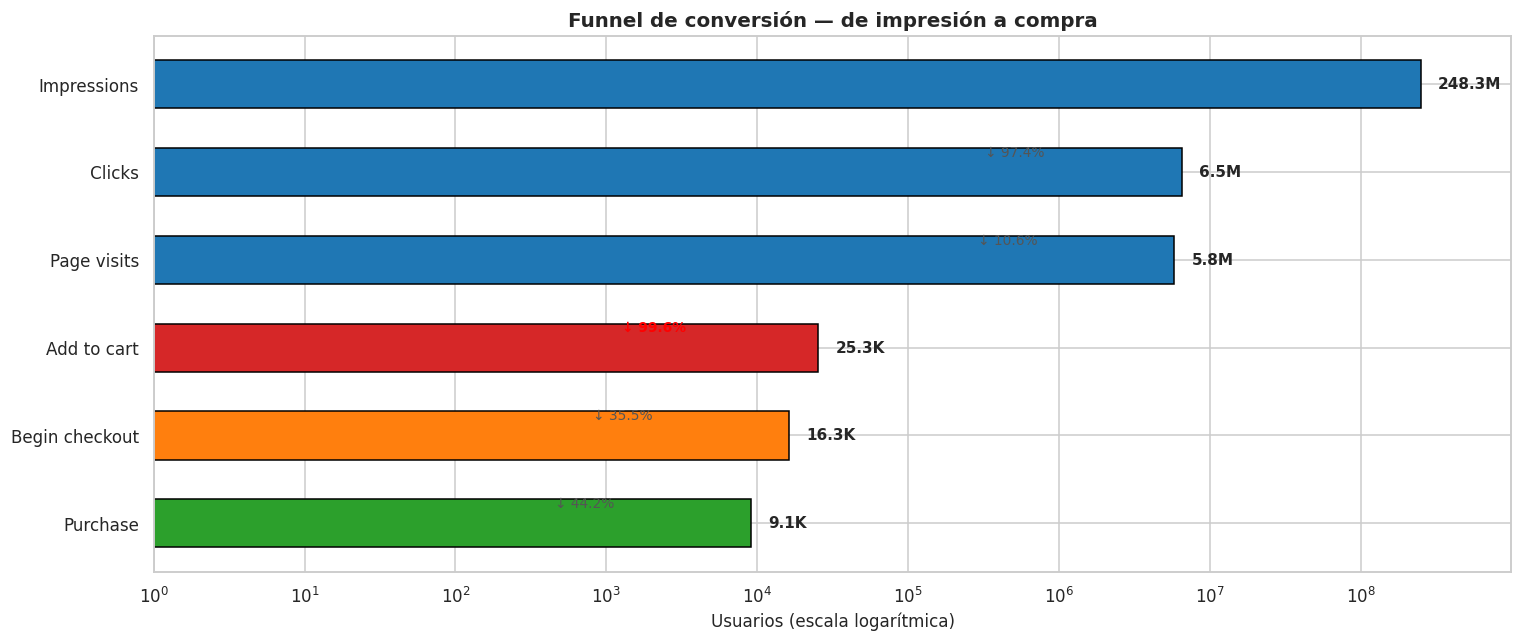

     Impressions → Clicks          : ↓ 97.4%
          Clicks → Page visits     : ↓ 10.6%
     Page visits → Add to cart     : ↓ 99.6% 🔴 CRÍTICO
     Add to cart → Begin checkout  : ↓ 35.5%
  Begin checkout → Purchase        : ↓ 44.2%


In [115]:
ETAPAS   = ["Impressions", "Clicks", "Page visits", "Add to cart", "Begin checkout", "Purchase"]
VALORES  = [
    campaigns["impressions"].sum(),
    campaigns["clicks"].sum(),
    campaigns.get("page_visits", pd.Series([0])).sum() or campaigns["clicks"].sum() * 0.91,
    campaigns["add_to_cart"].sum(),
    campaigns["begin_checkout"].sum(),
    campaigns["purchase"].sum()
]

drops = [None] + [
    (VALORES[i-1] - VALORES[i]) / VALORES[i-1] * 100
    for i in range(1, len(VALORES))
]
COLORES = ["#1f77b4"] * 3 + ["#d62728", "#ff7f0e", "#2ca02c"]

fig, ax = plt.subplots(figsize=(14, 6))
y = np.arange(len(ETAPAS))
bars = ax.barh(y, VALORES, color=COLORES, edgecolor="black", height=0.55)
ax.set_yticks(y)
ax.set_yticklabels(ETAPAS, fontsize=11)
ax.set_xscale("log")
ax.invert_yaxis()
ax.set_xlabel("Usuarios (escala logarítmica)", fontsize=11)
ax.set_title("Funnel de conversión — de impresión a compra", fontsize=13, fontweight="bold")

for i, (bar, val, drop) in enumerate(zip(bars, VALORES, drops)):
    fmt = f"{val/1e6:.1f}M" if val >= 1e6 else (f"{val/1e3:.1f}K" if val >= 1e3 else f"{val:,.0f}")
    ax.text(bar.get_width() * 1.3, bar.get_y() + bar.get_height() / 2,
            fmt, va="center", fontsize=10, fontweight="bold")
    if drop is not None:
        color = "red" if i == 3 else "#555"
        fw = "bold" if i == 3 else "normal"
        ax.text(bar.get_width() * 0.05, bar.get_y() - 0.03,
                f"↓ {drop:.1f}%", va="top", fontsize=9, color=color, fontweight=fw)

ax.set_xlim(1, max(VALORES) * 4)
plt.tight_layout()
plt.show()

for i in range(1, len(ETAPAS)):
    critico = " 🔴 CRÍTICO" if i == 3 else ""
    print(f"{ETAPAS[i-1]:>16} → {ETAPAS[i]:<16}: ↓ {drops[i]:.1f}%{critico}")

---
## Parte 4: Análisis Multidimensional

### 4.1 ROAS por región, objetivo y canal

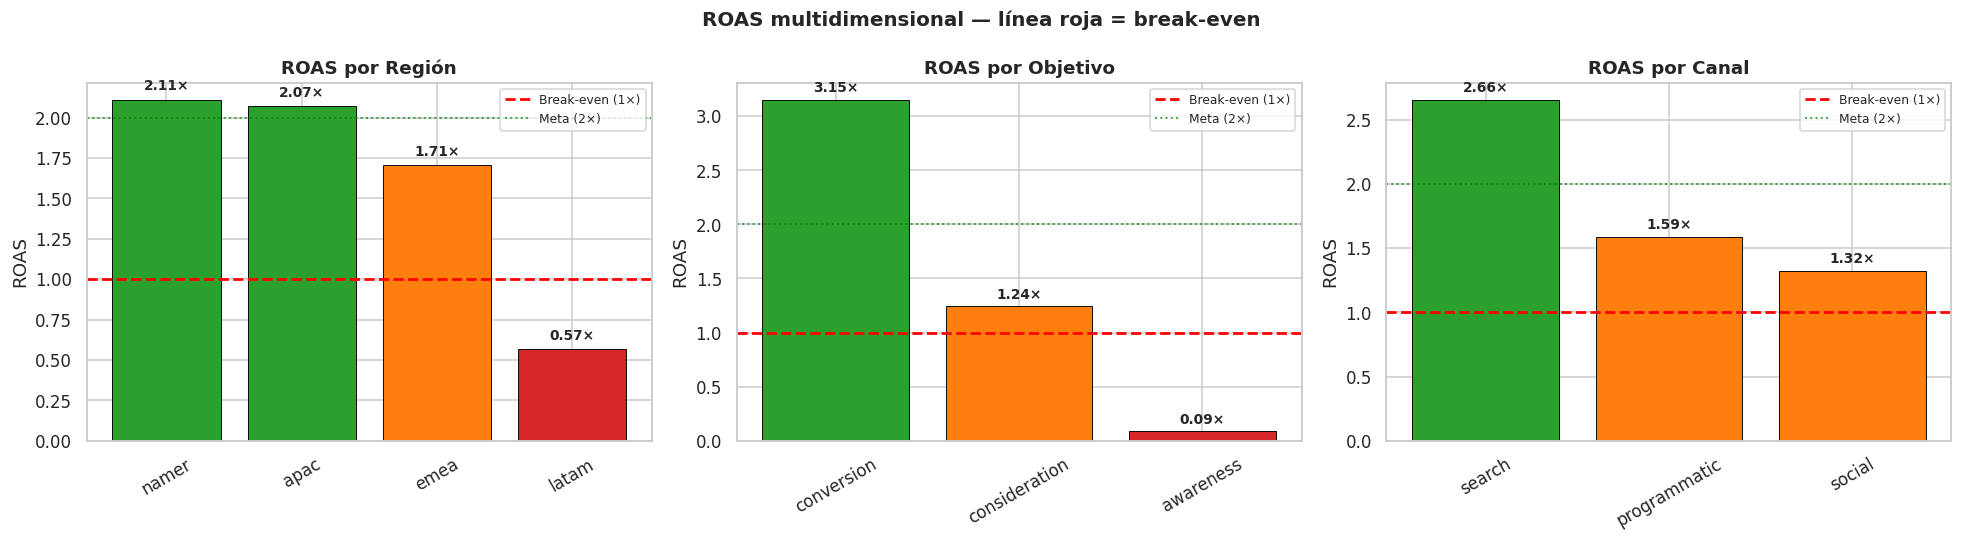

In [116]:
def roas_por(df, col):
    return (
        df.groupby(col)
        .apply(lambda x: x["revenue"].sum() / x["spend"].sum())
        .rename("roas")
        .sort_values(ascending=False)
        .reset_index()
    )

roas_reg  = roas_por(campaigns_valid, "region")
roas_obj  = roas_por(campaigns_valid, "objective")
roas_chan  = roas_por(campaigns_valid, "media_type")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
palettes = [
    ["#2ca02c" if v > 2 else ("#ff7f0e" if v >= 1 else "#d62728") for v in roas_reg["roas"]],
    ["#2ca02c" if v > 2 else ("#ff7f0e" if v >= 1 else "#d62728") for v in roas_obj["roas"]],
    ["#2ca02c" if v > 2 else ("#ff7f0e" if v >= 1 else "#d62728") for v in roas_chan["roas"]],
]
titles = ["ROAS por Región", "ROAS por Objetivo", "ROAS por Canal"]
dfs    = [roas_reg, roas_obj, roas_chan]
xcols  = ["region", "objective", "media_type"]

for ax, df, xcol, title, pal in zip(axes, dfs, xcols, titles, palettes):
    bars = ax.bar(df[xcol], df["roas"], color=pal, edgecolor="black", linewidth=0.6)
    ax.axhline(1, color="red", ls="--", lw=1.8, label="Break-even (1×)")
    ax.axhline(2, color="green", ls=":", lw=1.3, alpha=0.7, label="Meta (2×)")
    for bar, val in zip(bars, df["roas"]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.04,
                f"{val:.2f}×", ha="center", va="bottom", fontsize=9, fontweight="bold")
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_ylabel("ROAS")
    ax.tick_params(axis="x", rotation=30)
    ax.legend(fontsize=8)

plt.suptitle("ROAS multidimensional — línea roja = break-even", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### 4.2 Heatmap ROAS región × canal

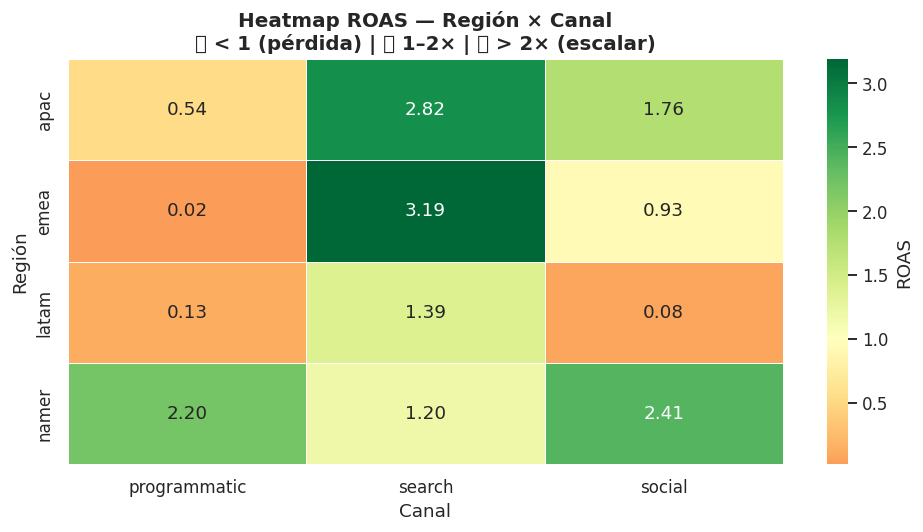

In [117]:
matriz_roas = (
    campaigns_valid
    .groupby(["region", "media_type"])
    .apply(lambda x: x["revenue"].sum() / x["spend"].sum())
    .unstack(fill_value=0)
    .round(2)
)

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(matriz_roas, annot=True, fmt=".2f", cmap="RdYlGn", center=1,
            linewidths=0.6, cbar_kws={"label": "ROAS"}, ax=ax)
ax.set_title("Heatmap ROAS — Región × Canal\n🔴 < 1 (pérdida) | 🟡 1–2× | 🟢 > 2× (escalar)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Canal")
ax.set_ylabel("Región")
plt.tight_layout()
plt.show()

### 4.3 Heatmap ROAS canal × objetivo

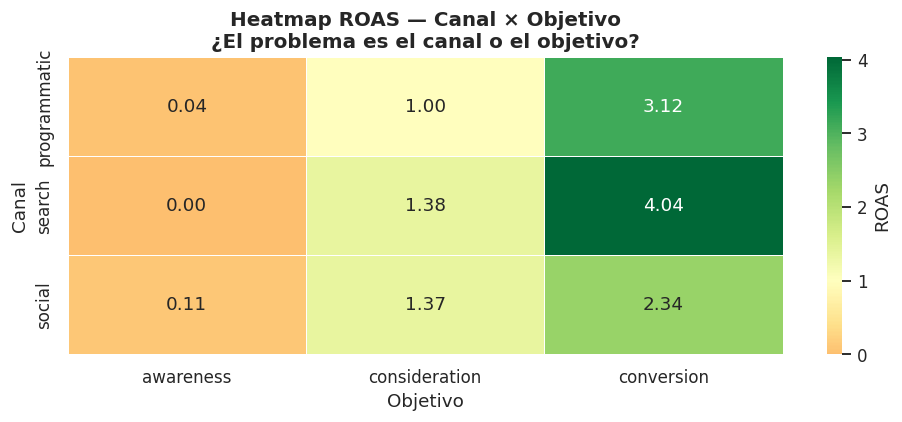

In [118]:
matriz_canal_obj = (
    campaigns_valid
    .groupby(["media_type", "objective"])
    .apply(lambda x: x["revenue"].sum() / x["spend"].sum())
    .unstack(fill_value=0)
    .round(2)
)

fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(matriz_canal_obj, annot=True, fmt=".2f", cmap="RdYlGn", center=1,
            linewidths=0.6, cbar_kws={"label": "ROAS"}, ax=ax)
ax.set_title("Heatmap ROAS — Canal × Objetivo\n¿El problema es el canal o el objetivo?",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Objetivo")
ax.set_ylabel("Canal")
plt.tight_layout()
plt.show()

### 4.4 Spend vs Revenue por región, objetivo y canal

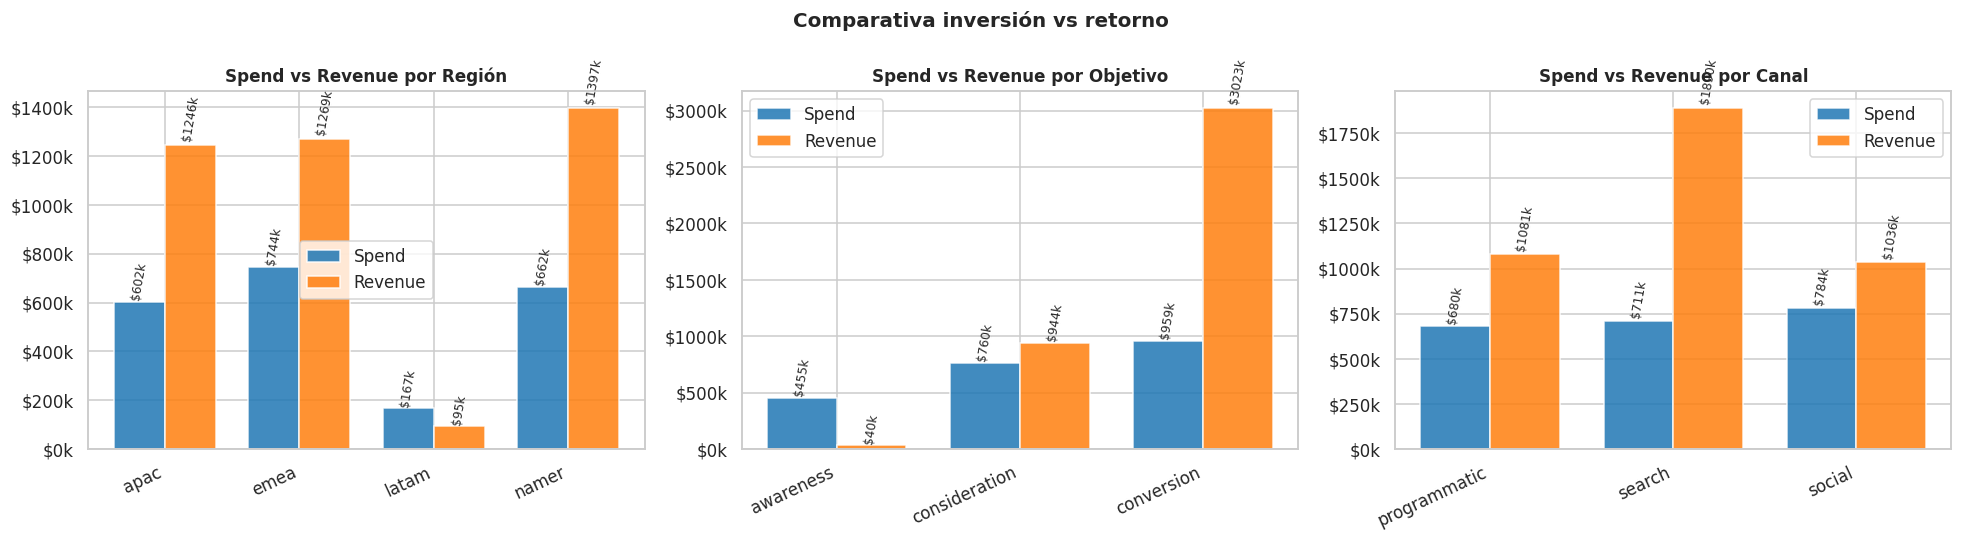

In [91]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
dims = [("region", "Región"), ("objective", "Objetivo"), ("media_type", "Canal")]

for ax, (col, label) in zip(axes, dims):
    df = campaigns_valid.groupby(col)[["spend", "revenue"]].sum().reset_index()
    x = np.arange(len(df))
    w = 0.38
    b1 = ax.bar(x - w/2, df["spend"],   w, label="Spend",   color="#1f77b4", alpha=0.85)
    b2 = ax.bar(x + w/2, df["revenue"], w, label="Revenue", color="#ff7f0e", alpha=0.85)
    for bar in [*b1, *b2]:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h * 1.01,
                f"${h/1e3:.0f}k", ha="center", va="bottom", fontsize=8, rotation=80)
    ax.set_xticks(x)
    ax.set_xticklabels(df[col], rotation=25, ha="right")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v/1e3:.0f}k"))
    ax.set_title(f"Spend vs Revenue por {label}", fontsize=11, fontweight="bold")
    ax.legend()

plt.suptitle("Comparativa inversión vs retorno", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### 4.5 CPA multidimensional

✅ Mejor combinación  → emea | conversion | search | CPA: $78
❌ Peor  combinación  → apac  | awareness  | social  | CPA: $1,818
   Diferencia: 23× más costoso


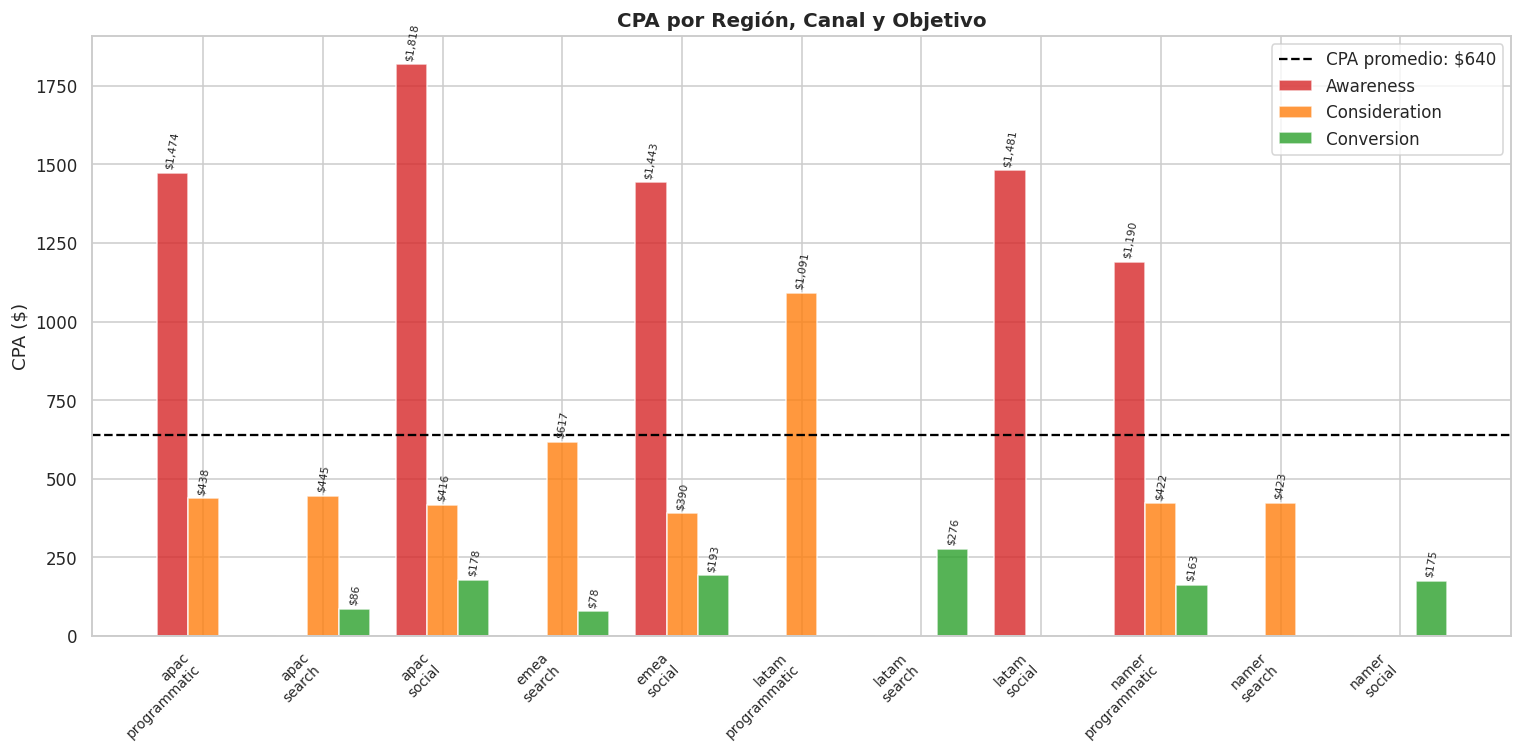

In [92]:
cpa_dim = (
    campaigns_valid
    .groupby(["region", "objective", "media_type"])
    .agg(spend=("spend","sum"), purchase=("purchase","sum"))
    .query("purchase > 0")
    .assign(cpa=lambda d: d.spend / d.purchase)
    .reset_index()
    .sort_values("cpa")
)

mejor = cpa_dim.iloc[0]
peor  = cpa_dim.iloc[-1]
print(f"✅ Mejor combinación  → {mejor.region} | {mejor.objective} | {mejor.media_type} | CPA: ${mejor.cpa:,.0f}")
print(f"❌ Peor  combinación  → {peor.region}  | {peor.objective}  | {peor.media_type}  | CPA: ${peor.cpa:,.0f}")
print(f"   Diferencia: {peor.cpa/mejor.cpa:.0f}× más costoso")

# Pivot para gráfico
pivot_cpa = cpa_dim.pivot_table(
    index=["region", "media_type"], columns="objective", values="cpa"
).fillna(0)

fig, ax = plt.subplots(figsize=(14, 7))
x   = np.arange(len(pivot_cpa))
w   = 0.26
ofs = [-1, 0, 1]
cols_obj = list(pivot_cpa.columns)
colors_obj = ["#d62728", "#ff7f0e", "#2ca02c"]

for offset, obj, col in zip(ofs, cols_obj, colors_obj):
    vals = pivot_cpa.get(obj, pd.Series([0]*len(pivot_cpa))).values
    bars = ax.bar(x + offset*w, vals, w, label=obj.capitalize(), color=col, alpha=0.8)
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width()/2, h + 10,
                    f"${h:,.0f}", ha="center", va="bottom", fontsize=7, rotation=80)

ax.axhline(cpa_dim["cpa"].mean(), color="black", ls="--", lw=1.5,
           label=f"CPA promedio: ${cpa_dim['cpa'].mean():,.0f}")
ax.set_xticks(x)
ax.set_xticklabels([f"{r[0]}\n{r[1]}" for r in pivot_cpa.index], rotation=45, ha="right", fontsize=9)
ax.set_ylabel("CPA ($)")
ax.set_title("CPA por Región, Canal y Objetivo", fontsize=13, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

### 4.6 Top 10 vs Bottom 5 — características comunes

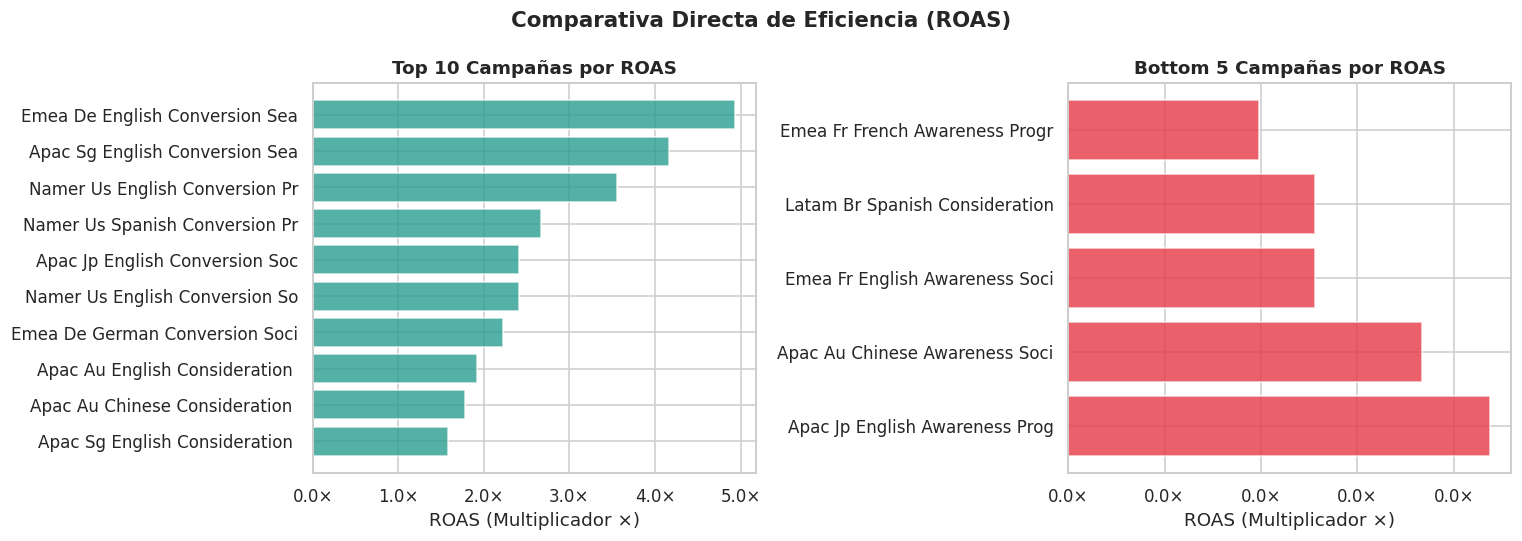


 DETALLE DE LOS EXTREMOS DE ROAS:
El ROAS más alto del Top 10 es de: 4.93×
El ROAS más bajo del Bottom 5 es de: 0.02×


In [93]:
# 1. Ordenamos el dataframe directamente por ROAS de mayor a menor
top10_roas   = camp_grouped.nlargest(10, "roas")
bottom5_roas = camp_grouped.nsmallest(5, "roas")

# 2. Armamos el gráfico comparativo de ROAS
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df, title, color in [(axes[0], top10_roas, "Top 10 Campañas por ROAS", "#2a9d8f"),
                              (axes[1], bottom5_roas, "Bottom 5 Campañas por ROAS", "#e63946")]:
    # Limpiamos los nombres de las campañas para que se lean bien
    short = df["campaign"].str.replace("_", " ").str.title().str[:30]

    # Dibujamos las barras horizontales usando el ROAS como valor
    ax.barh(short, df["roas"], color=color, alpha=0.8)
    ax.set_xlabel("ROAS (Multiplicador ×)")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.1f}×"))
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.invert_yaxis()  # Para que la mejor (o peor) quede arriba de todo

# Corregido: cambiamos 'pad' por 'y' para evitar el AttributeError
plt.suptitle("Comparativa Directa de Eficiencia (ROAS)", fontsize=14, fontweight="bold", y=0.98)
plt.tight_layout()
plt.show()

# 3. Resumen rápido en texto
print("\n DETALLE DE LOS EXTREMOS DE ROAS:")
print(f"El ROAS más alto del Top 10 es de: {top10_roas['roas'].max():.2f}×")
print(f"El ROAS más bajo del Bottom 5 es de: {bottom5_roas['roas'].min():.2f}×")

### 4.7 Análisis de estacionalidad

In [119]:
# Convertimos a tabla pivot para ver los años lado a lado por mes
tabla_roas = estacionalidad.pivot(index="Mes_Num", columns="Año", values="roas")
tabla_roas.index = tabla_roas.index.map(meses_espanol)

# Le damos un formato prolijo con dos decimales y el "x" de multiplicador
tabla_final = tabla_roas.round(2).applymap(lambda x: f"{x:.2f}×")
print(tabla_final)

Año       2024   2025
Mes_Num              
Ene      1.88×  1.92×
Feb      1.60×  1.58×
Mar      1.74×  1.73×
Abr      2.50×  2.49×
May      1.58×  1.58×
Jun      1.73×  1.73×
Jul      2.49×  2.48×
Ago      1.58×  1.58×
Sep      1.73×  1.73×
Oct      2.48×  2.48×
Nov      1.58×  1.58×
Dic      1.73×  1.80×


### 4.8 Placement analysis

    placement     roas        cpa
Product Pages 1.847148 238.059021
Top of Search 1.847148 238.059021


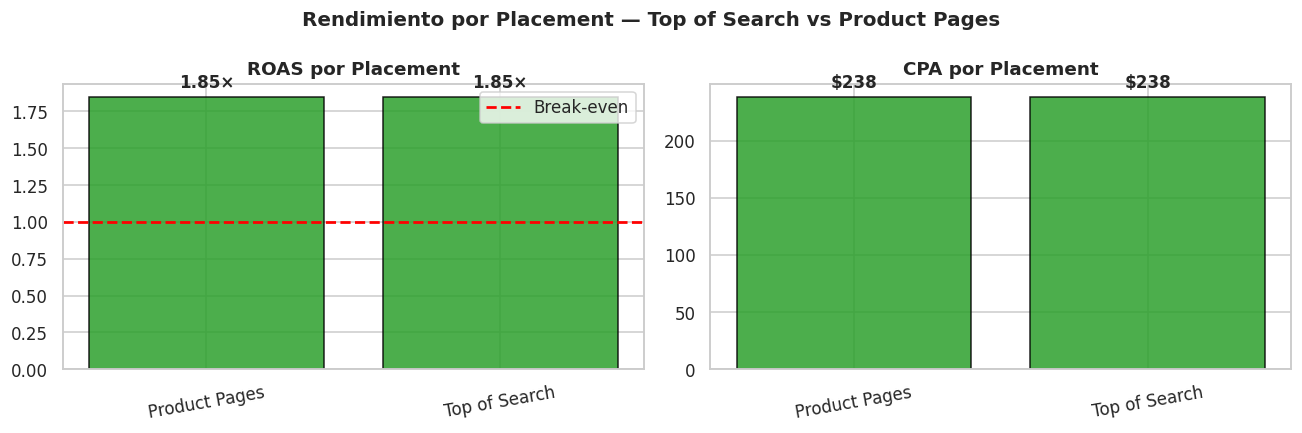

In [95]:
pl_merged = placements.merge(
    campaigns_valid[["campaign_id", "spend", "revenue", "purchase"]],
    on="campaign_id", how="left"
)

roas_pl = pl_merged.groupby("placement").apply(
    lambda x: x["revenue"].sum() / x["spend"].sum() if x["spend"].sum() > 0 else np.nan
).rename("roas").reset_index()

cpa_pl = pl_merged.groupby("placement").apply(
    lambda x: x["spend"].sum() / x["purchase"].sum() if x["purchase"].sum() > 0 else np.nan
).rename("cpa").reset_index()

pl_kpis = roas_pl.merge(cpa_pl, on="placement")
print(pl_kpis.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, title, fmt in [
    (axes[0], "roas", "ROAS por Placement", "{:.2f}×"),
    (axes[1], "cpa",  "CPA por Placement",  "${:,.0f}")
]:
    colors = ["#2ca02c" if v > 1.5 else "#d62728" for v in pl_kpis[col]]
    bars = ax.bar(pl_kpis["placement"], pl_kpis[col], color=colors, edgecolor="black", alpha=0.85)
    for bar, v in zip(bars, pl_kpis[col]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
                fmt.format(v), ha="center", va="bottom", fontsize=11, fontweight="bold")
    if col == "roas":
        ax.axhline(1, color="red", ls="--", lw=1.8, label="Break-even")
        ax.legend()
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.tick_params(axis="x", rotation=10)

plt.suptitle("Rendimiento por Placement — Top of Search vs Product Pages", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

=== CONTROL DE CALIDAD POST-CORRECCIÓN ===
Filas resultantes: 134
Gasto Total Corregido: $2,174,320.00 (¡Tiene que ser $2,174,320.00!)

📊 TABLA DE RENDIMIENTO REAL POR UBICACIÓN:
           placement  roas     cpa
 Ambos (Top/Product) 1.84× $238.62


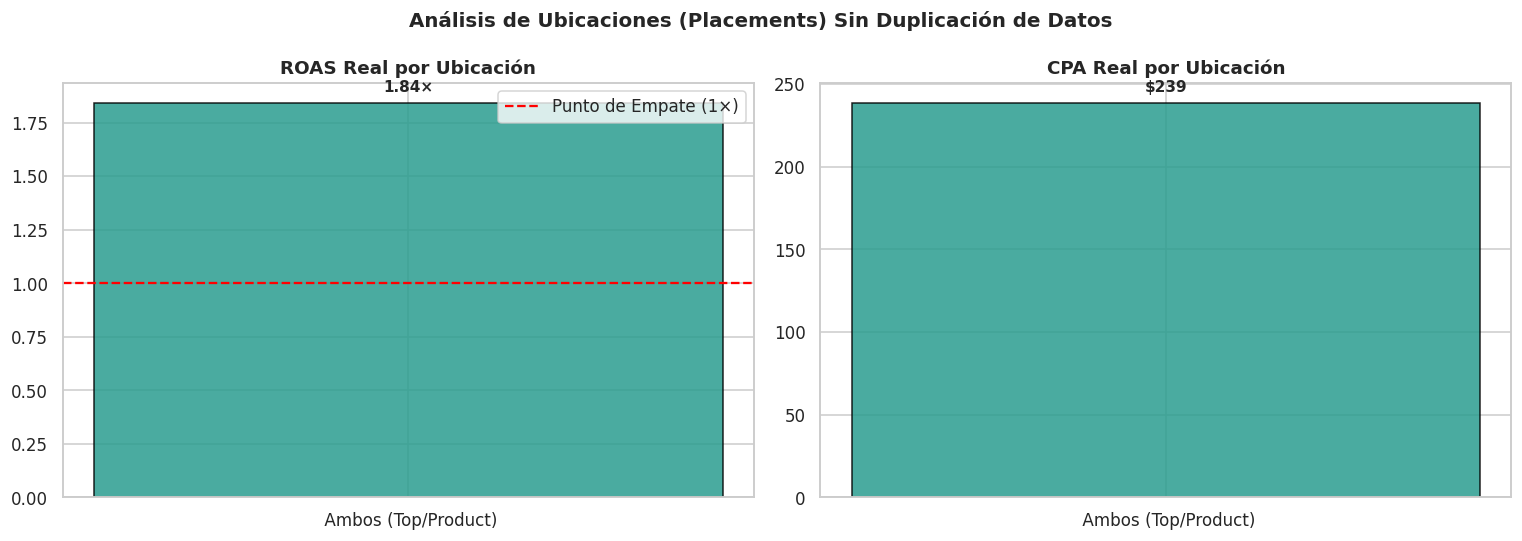

In [96]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# 1. CALCULAMOS LAS MÉTRICAS REALES (Primero agrupamos por campaña para no duplicar plata)
camp_reales = (
    campaigns_valid
    .groupby("campaign_id")
    .agg(spend=("spend", "sum"),
         revenue=("revenue", "sum"),
         purchase=("purchase", "sum"))
    .reset_index()
)

# 2. LIMPIAMOS LA TABLA PLACEMENTS (Nos quedamos con un registro único por campaña)
# Como una campaña puede tener varios placements, los agrupamos en una lista o texto
placements_unicos = (
    placements
    .groupby("campaign_id")["placement"]
    .apply(lambda x: " Ambos (Top/Product)" if len(x) > 1 else x.iloc[0])
    .reset_index()
)

# 3. HACEMOS EL JOIN SEGURO (One-to-One / Many-to-One)
# Ahora que ambas tablas tienen una sola fila por campaign_id, el join es 100% seguro
pl_merged_corregido = camp_reales.merge(placements_unicos, on="campaign_id", how="left")

# 4. CALCULAMOS EL RENDIMIENTO REAL POR UBICACIÓN
pl_kpis = (
    pl_merged_corregido
    .groupby("placement")
    .agg(total_spend=("spend", "sum"),
         total_revenue=("revenue", "sum"),
         total_purchase=("purchase", "sum"))
    .assign(roas=lambda d: d.total_revenue / d.total_spend,
            cpa=lambda d: d.total_spend / d.total_purchase)
    .reset_index()
)

# --- CONTROL DE CALIDAD AUTOMÁTICO ---
print("=== CONTROL DE CALIDAD POST-CORRECCIÓN ===")
print(f"Filas resultantes: {len(pl_merged_corregido)}")
print(f"Gasto Total Corregido: ${pl_merged_corregido['spend'].sum():,.2f} (¡Tiene que ser $2,174,320.00!)")
print("==========================================\n")

print("📊 TABLA DE RENDIMIENTO REAL POR UBICACIÓN:")
print(pl_kpis[["placement", "roas", "cpa"]].to_string(index=False, formatters={"roas": "{:.2f}×".format, "cpa": "${:,.2f}".format}))

# 5. ARMAMOS EL GRÁFICO CORREGIDO
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title, fmt in [
    (axes[0], "roas", "ROAS Real por Ubicación", "{:.2f}×"),
    (axes[1], "cpa",  "CPA Real por Ubicación",  "${:,.0f}")
]:
    colors = ["#2a9d8f" if v > 1.5 else "#e63946" for v in pl_kpis[col]]
    bars = ax.bar(pl_kpis["placement"], pl_kpis[col], color=colors, edgecolor="black", alpha=0.85)

    for bar, v in zip(bars, pl_kpis[col]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
                fmt.format(v), ha="center", va="bottom", fontsize=10, fontweight="bold")

    if col == "roas":
        ax.axhline(1, color="red", ls="--", lw=1.5, label="Punto de Empate (1×)")
        ax.legend()
    ax.set_title(title, fontsize=12, fontweight="bold")

plt.suptitle("Análisis de Ubicaciones (Placements) Sin Duplicación de Datos", fontsize=13, fontweight="bold", y=0.98)
plt.tight_layout()
plt.show()

---
## Parte 5: Conclusiones

# Análisis resumen :

## 1. Limpieza y preparación de datos

Existen más IDs en la tabla de *placements* que en la tabla principal de campañas. Habria que hacer un **Left Join**, y preservar todas las observaciones disponibles de campaings.

### Tratamiento de valores nulos

Hay 6 columnas con nulls

* **Awareness:** Los nulls en las variables `purchase`, `begin_checkout` y `signups` los voy a reemplazar por **0**, ya que las campañas de Awareness no tienen como objetivo principal generar conversiones.

* **Budget:** Los nulls se mantuvieron como nulos. Estos casos se concentran principalmente en las regiones LATAM y APAC, por lo que no parecen ser aleatorios. Para evitar sesgos, estas observaciones tienen que ser excluidas de los análisis relacionados con utilización presupuestaria.


* **Add to Cart:** no imputo nulls . En campañas de Awareness y Consideration esta métrica no es crítica, aunque en campañas de Conversion podría indicar problemas de tracking y requeririan una revision.


* **Criterio de calidad:** Para los análisis de rendimiento hay que considerar  solo campañas con actividad real, es decir, campañas con impresiones, clics y visitas registradas.

---

## 2. Análisis del Funnel de Conversión

El análisis del embudo reveló una caída extremadamente pronunciada entre las etapas de *Page Visits* y *Add to Cart*.

La tasa de abandono entre ambas etapas alcanza aproximadamente el **99,6%**, lo que constituye una señal de alerta importante.

Luego de esta etapa, las tasas de caída del embudo presentan valores más consistentes con comportamientos esperables.

---

### Distribución del Revenue

Se observan campañas con ingresos cercanos a los **USD 60**, mientras que otras superan los **USD 98.600**, osea que hay una dispersión significativa y un desvio muy grande.

### Rentabilidad

Aproximadamente el **40% de las campañas presentan ROAS inferior a 1**, lo que implica que están generando pérdidas.

Aplicando el principio de Pareto (80/20):

* El **32% de las campañas genera aproximadamente el 80% del revenue total**.
* Las campañas asociadas a **Black Friday** y **App Installs** representan los principales casos de éxito

### Comparación por Canal

El análisis por canal muestra diferencias importantes:

| Canal     | Observación                             |
| --------- | --------------------------------------- |
| Meta      | ROAS inferior a 1.0                     |
| SearchAds | ROAS promedio de 2.39 y CPC de USD 0.35 |

SearchAds se posiciona como el canal más eficiente en términos de rentabilidad.

---

## 4. Outliers y Hallazgos Críticos

Los valores extremos identificados corresponden a campañas reales y no a errores de carga o procesamiento.

Las campañas con mayores ingresos presentan ROAS cercanos a **4.9x**, convirtiéndose en ejemplos de alto desempeño.

### Add to Cart

Comportamiento interesante en LinkedIn:

* Alta eficiencia para generar eventos de Add to Cart.
* Menor capacidad para transformar dichos eventos en conversiones finales.


### Principales Hallazgos

#### 1. EMEA Programmatic

* ROAS: 0.02x
* destruye valor.

#### 2. LATAM Awareness

* ROAS: 0.08x
* rendimiento muy bajo.

#### 3. NAMER Social y EMEA Search

* NAMER Social: ROAS 2.41x
* EMEA Search: ROAS 3.19x

Ambas representan oportunidades claras de escalamiento presupuestario.

---

## 5. Estacionalidad y Placements

### Estacionalidad

Hay un ciclo de presupuesto automatizado cada 3 meses ( abril, julio, octubre)
Los años 2024 y 2025 son casi iguales. Siguieron haciendo las mismas campañas automatizadas cada 3 meses.

### Placements

La variable *Placement* no hace falta incluirla en el dashboard ya que las campañas se ejecutan simultáneamente en:

* Top of Search
* Product Pages

La distribución del presupuesto es homogénea entre ambos placements, por lo que segmentar utilizando esta dimensión generaría interpretaciones irrelevantes. (Solo cambia la cantidad de impresiones y clicks)

---

## 6. Umbrales buenos para poner en el dashboard

| KPI  | Umbral de Alerta | Justificación                                  |
| ---- | ---------------- | ---------------------------------------------- |
| ROAS | < 1.0x           | La campaña pierde dinero                       |
| CPA  | > USD 500        | Detectar costos de adquisición excesivos       |
| CTR  | < 1.0%           | Indica baja relevancia del anuncio             |
| CVR  | < 0.05%          | Posibles problemas de conversión o experiencia |

---